In [1]:
import pandas as pd
import seaborn as srn
import matplotlib.pyplot as plt

In [4]:
#importar dados
dataset = pd.read_csv("data/student_habits_performance.csv")
dataset

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [13]:
dataset.shape
print(dataset.shape)

(1000, 16)


In [14]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

<Axes: >

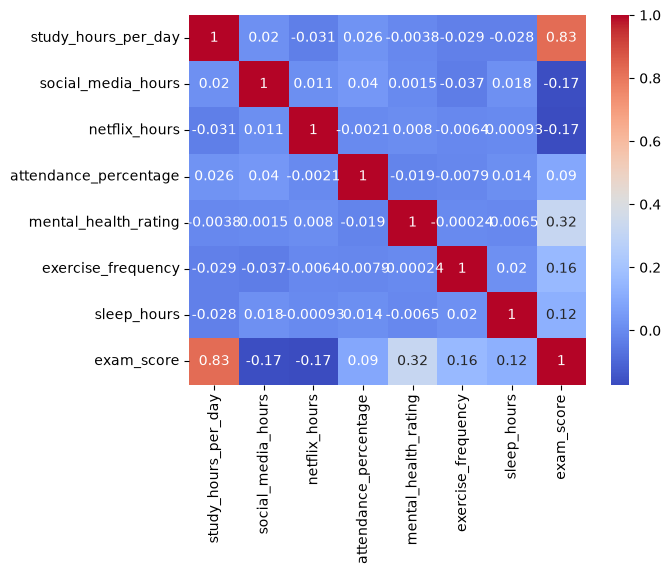

In [17]:
cols = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "mental_health_rating",
    "exercise_frequency",
    "sleep_hours",
    "exam_score",
]

srn.heatmap(dataset[cols].corr(), annot=True, cmap="coolwarm")

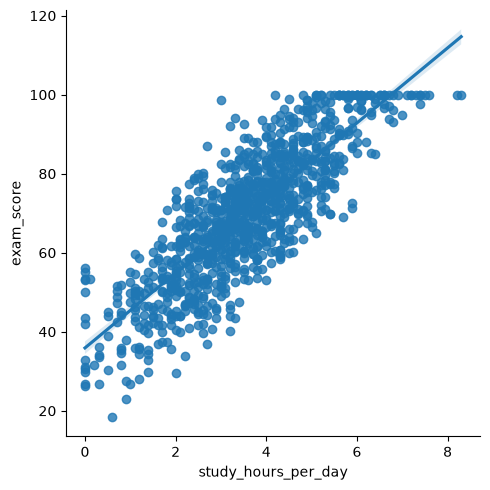

In [25]:
srn.lmplot(data=dataset, x="study_hours_per_day", y="exam_score")

In [26]:
# Comparando Médias: quem estuda >5H x <2H
filtro_estudo_alto = dataset["study_hours_per_day"] >5
filtro_estudo_baixo = dataset["study_hours_per_day"] <2

group_estudo_alto = dataset[filtro_estudo_alto]["exam_score"]
grupo_estudo_baixo = dataset[filtro_estudo_baixo]["exam_score"]

print('Média de notas (>5H):', group_estudo_alto.mean())
print("Média de notas (<2H):", grupo_estudo_baixo.mean())

Média de notas (>5H): 90.79419354838709
Média de notas (<2H): 45.56390977443609


<Axes: xlabel='social_media_hours', ylabel='Count'>

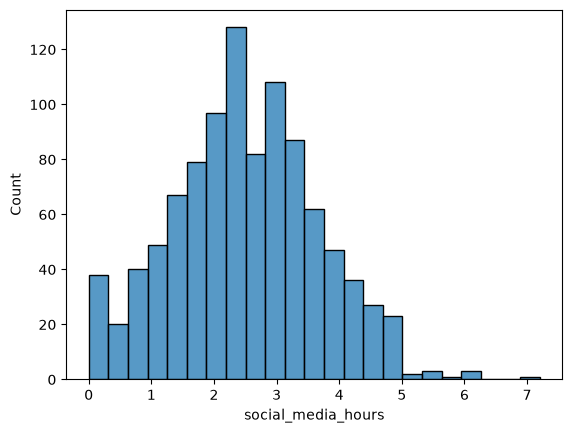

In [ ]:
# Histograma das redes sociais
srn.histplot(data=dataset, x="social_media_hours")

<Axes: xlabel='social_media_bin', ylabel='exam_score'>

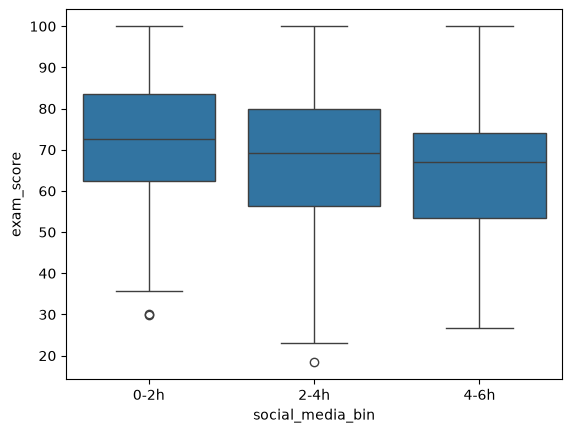

In [31]:
# Avaliando notas médias
# por diferentes intervalos (bins) de período em redes sociais
dataset["social_media_bin"]= pd.cut(
    dataset['social_media_hours'],
    bins=[0, 2, 4, 6],
    labels=["0-2h", "2-4h", "4-6h"]
)

srn.boxplot(x="social_media_bin", y="exam_score", data=dataset)

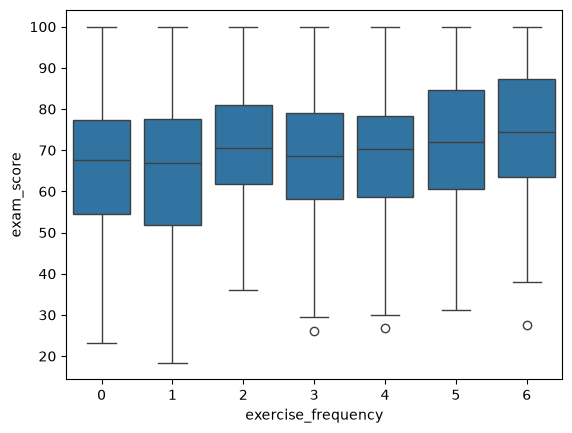

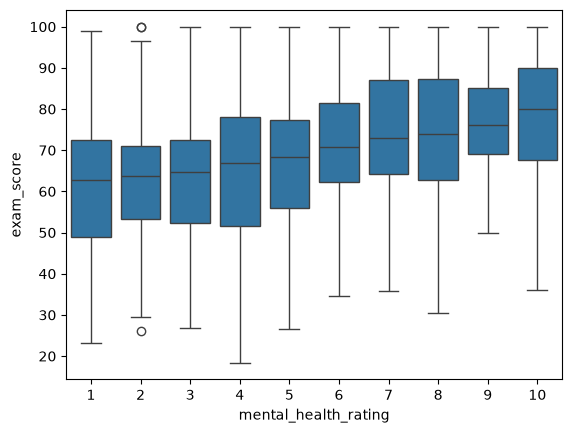

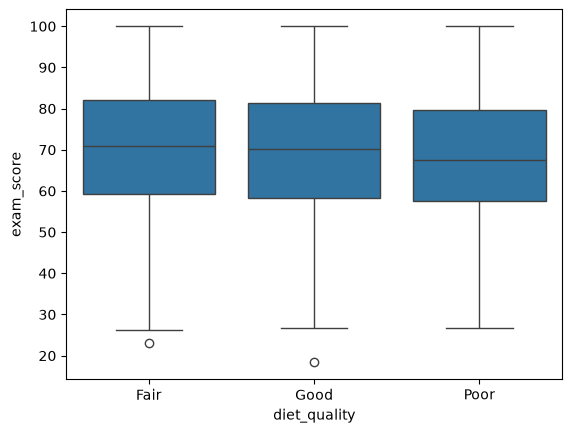

In [33]:
# Frequência de exercício físico
for col in ["exercise_frequency", "mental_health_rating", "diet_quality"]:
    srn.boxplot(x=col, y="exam_score", data=dataset)
    plt.show()

In [34]:
# Estatísticas por gênero (média e desvio de padrão)
dataset.groupby(["gender"])["exam_score"].agg(["mean", "std"])

,mean,std
gender,,
Female,69.741372,16.899351
Male,69.368344,17.150875
Other,70.647619,13.755890


In [35]:
# Avaliar distribuição de gênero
dataset["gender"].value_counts(normalize=True)

gender
Female    0.481
Male      0.477
Other     0.042
Name: proportion, dtype: float64